# protpy Tutorial — Protein Descriptor Walkthrough

**`protpy`** is a Python package for generating physicochemical, biochemical and structural
descriptors for protein sequences directly from primary sequence data.

This notebook walks through:
- All major descriptor categories with code examples and visualisations
- The new `get_descriptor_info()` / `list_descriptors()` utilities from `protpy.utils`
- f-string modernisation patterns used throughout the codebase
- Type-hint enhancements applied to every module
- Per-descriptor performance benchmarks

---
**Requirements:** `protpy`, `pandas`, `numpy`, `matplotlib`, `seaborn`


## 1. Import Libraries & Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), ""))

import warnings
warnings.filterwarnings("ignore")

import protpy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import timeit
from typing import Union, Optional
from protpy.utils import get_descriptor_info, list_descriptors, print_descriptor_info

# ── Plot style ──────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 11, "axes.labelsize": 10})

# ── Sample protein sequences (varying length & physicochemical character) ────
SEQ_SHORT   = "MAEGEITTFTALTEKFNLPPGNYKKPKLLYCSNGGHFLRILPDGTVDGTRDRSDQHIQLQLSAESVGEVYIKSTETGQYLAMDTSGLLYGSQTPSEECLFLERLEENHYNTYTSKKHAEKNWFVGLKKNGSCKRGPRTHYGQKAILFLPLPV"
SEQ_MEDIUM  = "MKTAYIAKQRQISFVKSHFSRQLEERLGLIEVQAPILSRVGDGTQDNLSGAEKAVQVKVKALPDAQFEVVHSLAKWKRQTLGQHDFSAGEGLYTHMKALRPDEDRLSPLHSVYVDQWDWERVMGDGERQFSTLKSTVEAIWAGIKATEAAVSEEFGLAPFLPDQIHFVHSQELLSRYPDLDAKGRERAIAKDLGAVFLVGIGGKLSDGHRHDVRAPDYDDWSTPSELGHAGLNGDILVWNPVLEDAFELSSMGIRVDADTLKHQLALTGDEDRLELEWHQALLRGEMPQTIGGGIGQSRLTMLLLQLPHIGQVQAGVWPAAVRESVPSLL"
SEQ_HELICAL = "ACDEFGHIKLMNPQRSTVWY" * 5  # artificial length-100 sequence
SEQ_ACIDIC  = "DDDEEEDDDEEEDDDEEEDD" * 5  # predominantly acidic

# ── Named dict used in the dashboard cell ────────────────────────────────────
SEQUENCES = {"Short": SEQ_SHORT, "Helical": SEQ_HELICAL, "Acidic": SEQ_ACIDIC}

print(f"protpy version : {protpy.__version__}")
print(f"Short seq len  : {len(SEQ_SHORT)}")
print(f"Medium seq len : {len(SEQ_MEDIUM)}")
print(f"Helical seq len: {len(SEQ_HELICAL)}")
print(f"Acidic seq len : {len(SEQ_ACIDIC)}")


protpy version : 1.3.0
Short seq len  : 152
Medium seq len : 330
Helical seq len: 100
Acidic seq len : 100


## 2. Enhanced Type Hints

All public functions now use `list[str]`, `dict[str, float]`, `tuple[float, float]`, and `pd.DataFrame` return annotations instead of bare `list` / `dict`.  
Below are representative before/after examples drawn directly from `protpy`'s source.

In [2]:
import inspect, protpy.autocorrelation as _auto, protpy.composition as _comp

# ── Before: bare list / dict annotations ── (old signatures, shown as strings)
BEFORE = {
    "moreaubroto_autocorrelation": "properties: list = [...]",
    "pseudo_amino_acid_composition": "properties: list = []",
    "sequence_order_correlation_factor": "properties: list = []",
    "correlation_function": "properties: list = []",
    "normalize_property": "properties: dict  ->  dict",
    "_std (composition)": "prop  ->  float",
    "amphiphilic_sequence_order_correlation_factor": "->  list",
    "amphiphilic_correllation_function": "->  list",
}

# ── After: specific subscripted annotations ─────────────────────────────────
AFTER = {
    "moreaubroto_autocorrelation": "properties: list[str] = [...]",
    "pseudo_amino_acid_composition": "properties: list[str] = []",
    "sequence_order_correlation_factor": "properties: list[dict[str, float]] = []",
    "correlation_function": "properties: list[dict[str, float]] = []",
    "normalize_property": "properties: dict[str, float]  ->  dict[str, float]",
    "_std (composition)": "prop: list[float]  ->  float",
    "amphiphilic_sequence_order_correlation_factor": "->  list[float]",
    "amphiphilic_correllation_function": "->  tuple[float, float]",
}

cmp = pd.DataFrame({"Before": BEFORE, "After": AFTER})
cmp.index.name = "function"
cmp.style.set_caption("Type-hint upgrades applied in protpy v1.3").set_properties(
    **{"text-align": "left", "font-size": "12px"}
)


,Before,After
function,,
moreaubroto_autocorrelation,properties: list = [...],properties: list[str] = [...]
pseudo_amino_acid_composition,properties: list = [],properties: list[str] = []
sequence_order_correlation_factor,properties: list = [],"properties: list[dict[str, float]] = []"
correlation_function,properties: list = [],"properties: list[dict[str, float]] = []"
normalize_property,properties: dict -> dict,"properties: dict[str, float] -> dict[str, float]"
_std (composition),prop -> float,prop: list[float] -> float
amphiphilic_sequence_order_correlation_factor,-> list,-> list[float]
amphiphilic_correllation_function,-> list,"-> tuple[float, float]"


## 3. F-String Modernisation

All `.format()` and `%`-style string formatting across the package has been replaced with f-strings.  
Below are the most representative before/after pairs.

In [3]:
examples = {
    # ── autocorrelation.py ───────────────────────────────────────────────────
    "autocorrelation — invalid property": {
        "before": '"Property {} not found in aaindex1:\\n{}.".format(prop, properties)',
        "after":  'f"Property {prop} not found in aaindex1:\\n{properties}."',
    },
    # ── composition.py ──────────────────────────────────────────────────────
    "composition — kmer ValueError": {
        "before": '"k={} would generate {:,} columns.".format(k, 20**k)',
        "after":  'f"k={k} would generate {20**k:,} columns."',
    },
    "composition — reduced alphabet column": {
        "before": '"ReducedAlphabet_{}".format(idx + 1)',
        "after":  'f"ReducedAlphabet_{idx + 1}"',
    },
    "composition — pair label": {
        "before": '"{}{}_{}" .format(i, j, _aa_class(i) + "-" + _aa_class(j))',
        "after":  'f"{i}{j}_{_aa_class(i)}-{_aa_class(j)}"',
    },
    "composition — aaindex1 lookup": {
        "before": "'Accession number not found in aaindex1: {}.'.format(prop)",
        "after":  'f"Accession number not found in aaindex1: {prop}."',
    },
    # ── ctd.py ──────────────────────────────────────────────────────────────
    "ctd — invalid property": {
        "before": '"Invalid property \'{}\'.".format(property, ...)',
        "after":  'f"Invalid property \'{property}\'."',
    },
    # ── sequence_order.py ───────────────────────────────────────────────────
    "sequence_order — JSON decode error": {
        "before": "'Error parsing distance matrix JSON file: {}.'.format(distance_matrix)",
        "after":  'f"Error parsing distance matrix JSON file: {distance_matrix}."',
    },
    "sequence_order — invalid lag": {
        "before": '"Invalid lag value input: {}.".format(lag)',
        "after":  'f"Invalid lag value input: {lag}."',
    },
    # ── _constants.py ───────────────────────────────────────────────────────
    "_constants — bad type": {
        "before": '"Input sequence must be a string, got input of type {}.".format(type(sequence))',
        "after":  'f"Input sequence must be a string, got input of type {type(sequence)}."',
    },
    "_constants — invalid aa": {
        "before": '"Invalid amino acid found in protein sequence: {}.".format(aa)',
        "after":  'f"Invalid amino acid found in protein sequence: {aa}."',
    },
}

fstr_df = pd.DataFrame(examples).T
fstr_df.index.name = "location"
fstr_df.style.set_caption("f-string modernisation — 20 changes across 5 modules").set_properties(
    **{"text-align": "left", "font-size": "11px"}
)


,before,after
location,,
autocorrelation — invalid property,"""Property {} not found in aaindex1:\n{}."".format(prop, properties)","f""Property {prop} not found in aaindex1:\n{properties}."""
composition — kmer ValueError,"""k={} would generate {:,} columns."".format(k, 20**k)","f""k={k} would generate {20**k:,} columns."""
composition — reduced alphabet column,"""ReducedAlphabet_{}"".format(idx + 1)","f""ReducedAlphabet_{idx + 1}"""
composition — pair label,"""{}{}_{}"" .format(i, j, _aa_class(i) + ""-"" + _aa_class(j))","f""{i}{j}_{_aa_class(i)}-{_aa_class(j)}"""
composition — aaindex1 lookup,'Accession number not found in aaindex1: {}.'.format(prop),"f""Accession number not found in aaindex1: {prop}."""
ctd — invalid property,"""Invalid property '{}'."".format(property, ...)","f""Invalid property '{property}'."""
sequence_order — JSON decode error,'Error parsing distance matrix JSON file: {}.'.format(distance_matrix),"f""Error parsing distance matrix JSON file: {distance_matrix}."""
sequence_order — invalid lag,"""Invalid lag value input: {}."".format(lag)","f""Invalid lag value input: {lag}."""
_constants — bad type,"""Input sequence must be a string, got input of type {}."".format(type(sequence))","f""Input sequence must be a string, got input of type {type(sequence)}."""


## 4. Utils Module — `protpy.utils`

`protpy/utils.py` is a new module that centralises:
- `get_descriptor_info(name)` — structured metadata lookup
- `list_descriptors(category)` — filtered descriptor discovery
- `print_descriptor_info(name)` — pretty-print to stdout

In [4]:
from protpy.utils import get_descriptor_info, list_descriptors, print_descriptor_info

# ── All registered descriptors ───────────────────────────────────────────────
all_names = list_descriptors()
print(f"Total registered descriptors: {len(all_names)}\n")

# ── List by category ─────────────────────────────────────────────────────────
for cat in ["Composition", "Autocorrelation", "Conjoint Triad", "CTD", "Sequence Order"]:
    names = list_descriptors(cat)
    print(f"{cat:20s}: {len(names):2d}  →  {names}")


Total registered descriptors: 36

Composition         : 23  →  ['aggregation_propensity', 'aliphatic_index', 'amino_acid_composition', 'amino_acid_pair_composition', 'amphiphilic_pseudo_amino_acid_composition', 'aromaticity', 'boman_index', 'charge_distribution', 'dipeptide_composition', 'extinction_coefficient', 'gravy', 'hydrophobic_moment', 'hydrophobic_polar_charged_composition', 'instability_index', 'isoelectric_point', 'kmer_composition', 'molecular_weight', 'motif_composition', 'pseudo_amino_acid_composition', 'reduced_alphabet_composition', 'secondary_structure_propensity', 'shannon_entropy', 'tripeptide_composition']
Autocorrelation     :  3  →  ['geary_autocorrelation', 'moran_autocorrelation', 'moreaubroto_autocorrelation']
Conjoint Triad      :  1  →  ['conjoint_triad']
CTD                 :  4  →  ['ctd_', 'ctd_composition', 'ctd_distribution', 'ctd_transition']
Sequence Order      :  5  →  ['quasi_sequence_order', 'quasi_sequence_order_all', 'sequence_order_coupling_numbe

## 5. `get_descriptor_info()` — Descriptor Metadata Lookup

In [5]:
# ── Dict return value ─────────────────────────────────────────────────────────
info = get_descriptor_info("amino_acid_composition")
for key, val in info.items():
    print(f"  {key:<15}: {val}")


  name           : amino_acid_composition
  description    : Fraction of each of the 20 canonical amino acids in the sequence. AA_Comp(s) = AA(t) / N(s).
  module         : composition
  category       : Composition
  abbreviation   : AAComp
  parameters     : {'sequence': 'str — protein sequence'}
  output_shape   : 1 x 20
  speed          : Fast
  reference      : [1] Gromiha, M. M. (2010). Protein Bioinformatics. Elsevier.


In [6]:
# ── Build a summary table of all descriptors ─────────────────────────────────
rows = []
for name in list_descriptors():
    info = get_descriptor_info(name)
    rows.append({
        "descriptor": name,
        "abbreviation": info["abbreviation"],
        "category": info["category"],
        "output_shape": info["output_shape"],
        "speed": info["speed"],
    })

registry_df = pd.DataFrame(rows).set_index("descriptor")
registry_df.style.set_caption("protpy Descriptor Registry")


,abbreviation,category,output_shape,speed
descriptor,,,,
aggregation_propensity,AggregProp,Composition,"1 x 2 [AggregProneRegions, AggregProneFraction]",Fast
aliphatic_index,AI,Composition,1 x 1,Fast
amino_acid_composition,AAComp,Composition,1 x 20,Fast
amino_acid_pair_composition,PairComp,Composition,1 x 400,Moderate
amphiphilic_pseudo_amino_acid_composition,APAAComp,Composition,1 x (20 + 2·lamda) (default 1 x 80),Moderate
aromaticity,Aromaticity,Composition,1 x 1,Fast
boman_index,BI,Composition,1 x 1,Fast
charge_distribution,ChargeDist,Composition,1 x 3,Fast
conjoint_triad,CTriad,Conjoint Triad,1 x 343,Fast


## 6. Amino Acid Composition Descriptors

The simplest family of descriptors counts how frequently each of the 20 standard amino acids (and their combinations) appears in a sequence.

In [7]:
import matplotlib.pyplot as plt

# ── Amino acid composition (20 features) ─────────────────────────────────────
aac = protpy.amino_acid_composition(SEQ_SHORT)
print(f"Shape: {aac.shape}  |  Sum: {aac.values.sum():.4f}")
aac


Shape: (1, 20)  |  Sum: 99.9980


,A,C,D,E,F,G,H,I,K,L,M,N,P,Q,R,S,T,V,W,Y
0,3.947,1.974,3.289,7.895,3.947,9.211,3.289,3.289,7.895,11.842,1.316,4.605,5.263,3.947,3.947,6.579,8.553,3.289,0.658,5.263


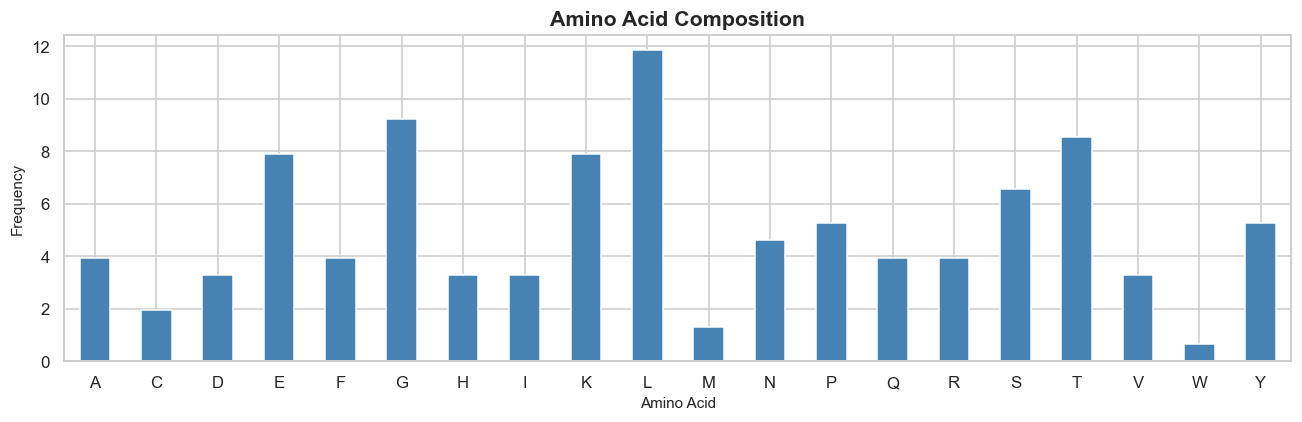

In [8]:
# ── Bar chart of amino acid frequencies ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
aac.T.plot(kind="bar", ax=ax, legend=False, color="steelblue", edgecolor="white")
ax.set_title("Amino Acid Composition", fontsize=14, fontweight="bold")
ax.set_xlabel("Amino Acid")
ax.set_ylabel("Frequency")
ax.set_xticklabels(list(aac.columns), rotation=0)
plt.tight_layout()
plt.show()


## 7. Dipeptide & Tripeptide Composition

Dipeptide composition (400 features) and tripeptide composition (8000 features) capture pairwise and triplet residue co-occurrence patterns.

Dipeptide composition shape: (1, 400)


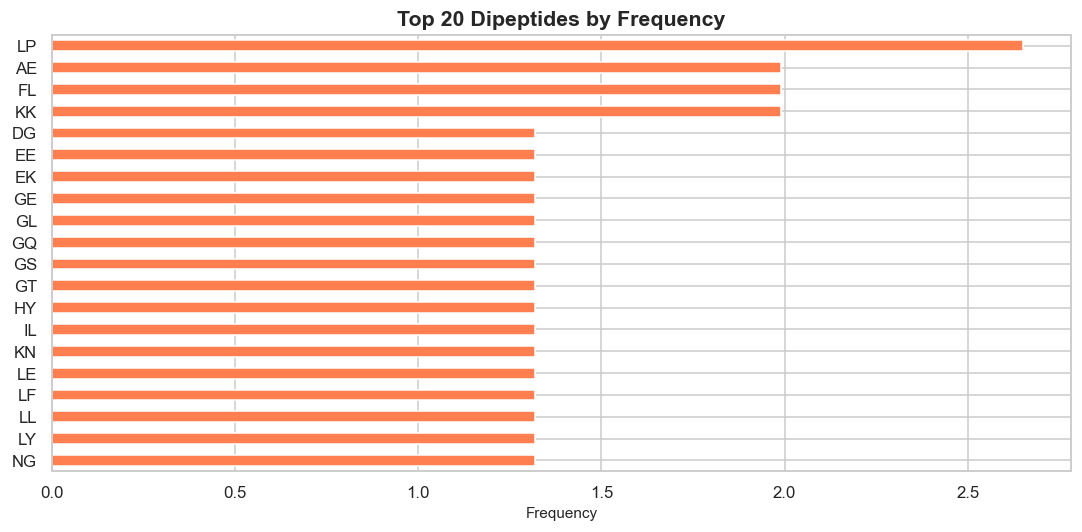

In [9]:
# ── Dipeptide composition (400 features) ─────────────────────────────────────
dpc = protpy.dipeptide_composition(SEQ_SHORT)
print(f"Dipeptide composition shape: {dpc.shape}")

# ── Top-20 most frequent dipeptides ──────────────────────────────────────────
top_dp = dpc.T.squeeze().nlargest(20)
fig, ax = plt.subplots(figsize=(10, 5))
top_dp.plot(kind="barh", ax=ax, color="coral", edgecolor="white")
ax.set_title("Top 20 Dipeptides by Frequency", fontsize=14, fontweight="bold")
ax.set_xlabel("Frequency")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


Tripeptide composition: 8000 total features, 147 non-zero


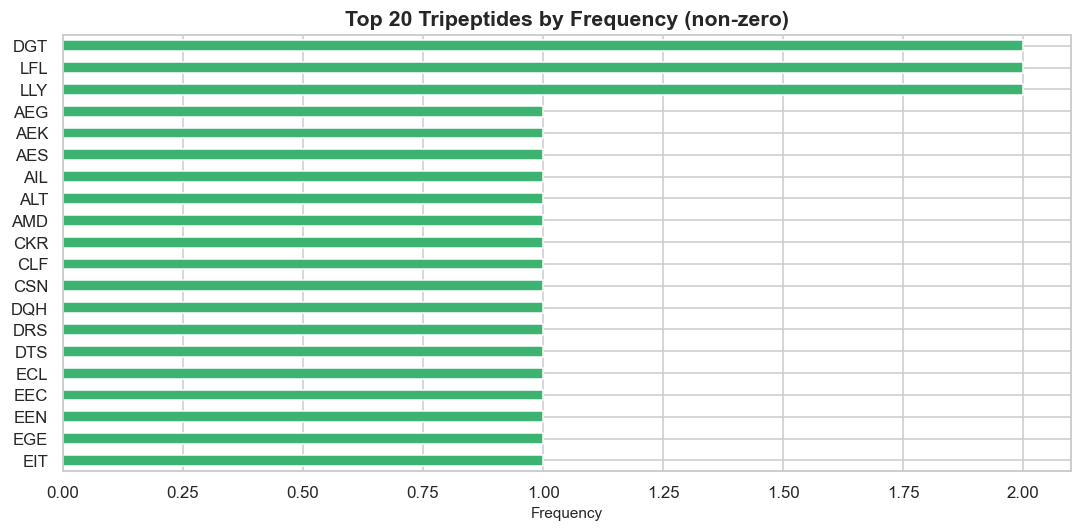

In [10]:
# ── Tripeptide composition (8000 features, only non-zero shown) ───────────────
tpc = protpy.tripeptide_composition(SEQ_SHORT)
non_zero = tpc.T.squeeze()[tpc.T.squeeze() > 0]
print(f"Tripeptide composition: {tpc.shape[1]} total features, {len(non_zero)} non-zero")

top_tp = non_zero.nlargest(20)
fig, ax = plt.subplots(figsize=(10, 5))
top_tp.plot(kind="barh", ax=ax, color="mediumseagreen", edgecolor="white")
ax.set_title("Top 20 Tripeptides by Frequency (non-zero)", fontsize=14, fontweight="bold")
ax.set_xlabel("Frequency")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


## 8. Autocorrelation Descriptors

Autocorrelation descriptors measure the correlation between physicochemical property values at residues separated by a lag distance *d*.  
protpy provides three variants — **MoreauBroto**, **Moran**, and **Geary** — each computed over up to 30 lags and a configurable set of AAIndex properties.

In [11]:
# ── Compute all three autocorrelation descriptors ────────────────────────────
moreau = protpy.moreaubroto_autocorrelation(SEQ_SHORT)
moran  = protpy.moran_autocorrelation(SEQ_SHORT)
geary  = protpy.geary_autocorrelation(SEQ_SHORT)

print(f"MoreauBroto shape : {moreau.shape}")
print(f"Moran shape       : {moran.shape}")
print(f"Geary shape       : {geary.shape}")


MoreauBroto shape : (1, 240)
Moran shape       : (1, 240)
Geary shape       : (1, 240)


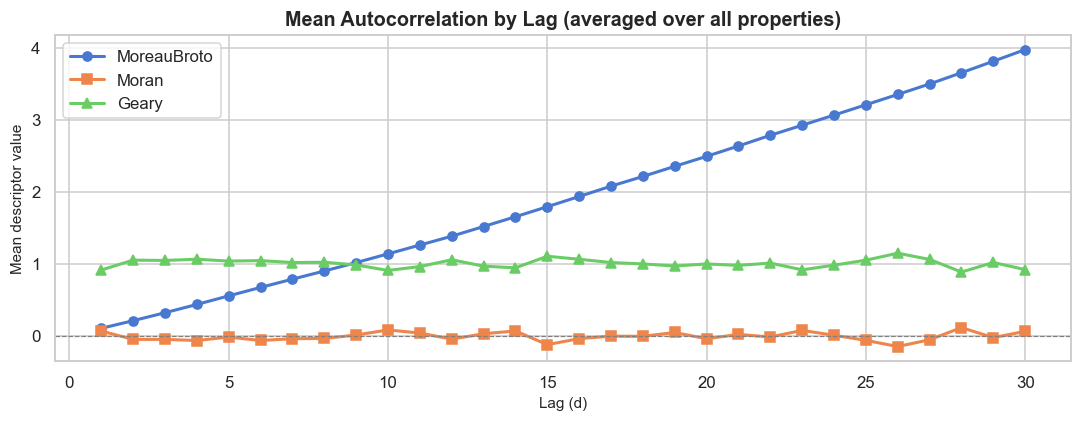

In [12]:
# ── Plot mean autocorrelation value by lag for each descriptor ────────────────
import numpy as np

# Default properties produce 30 lags each; reshape into (num_props, 30) and average
n_lags = 30
n_props = moreau.shape[1] // n_lags

def mean_by_lag(df, n_lags):
    arr = df.values.reshape(n_props, n_lags)
    return arr.mean(axis=0)

lags = np.arange(1, n_lags + 1)
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(lags, mean_by_lag(moreau, n_lags), marker="o", label="MoreauBroto", linewidth=2)
ax.plot(lags, mean_by_lag(moran,  n_lags), marker="s", label="Moran",       linewidth=2)
ax.plot(lags, mean_by_lag(geary,  n_lags), marker="^", label="Geary",       linewidth=2)
ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
ax.set_title("Mean Autocorrelation by Lag (averaged over all properties)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Lag (d)")
ax.set_ylabel("Mean descriptor value")
ax.legend()
plt.tight_layout()
plt.show()


## 9. CTD Descriptors

CTD (Composition / Transition / Distribution) descriptors encode the distribution of residue classes within a sequence using a 3-state alphabet derived from any physicochemical property.

In [13]:
# ── Compute individual CTD components ────────────────────────────────────────
ctd_comp = protpy.ctd_composition(SEQ_SHORT)
ctd_tran = protpy.ctd_transition(SEQ_SHORT)
ctd_dist = protpy.ctd_distribution(SEQ_SHORT)
ctd_all  = protpy.ctd_(SEQ_SHORT)   # combined CTD (composition+transition+distribution)

print(f"CTD Composition  : {ctd_comp.shape}")
print(f"CTD Transition   : {ctd_tran.shape}")
print(f"CTD Distribution : {ctd_dist.shape}")
print(f"CTD (combined)   : {ctd_all.shape}")


CTD Composition  : (1, 3)
CTD Transition   : (1, 3)
CTD Distribution : (1, 15)
CTD (combined)   : (1, 147)


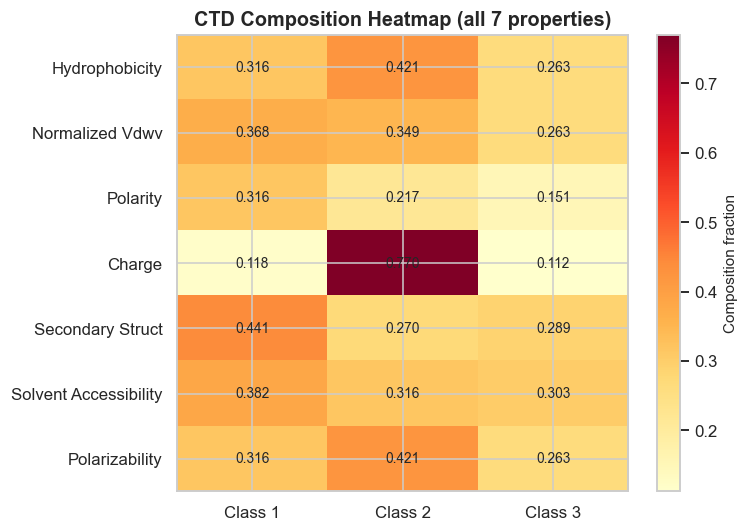

In [14]:
# ── Compute CTD composition for all 7 built-in properties ────────────────────
from protpy.ctd import ctd_properties

prop_names = list(ctd_properties.keys())   # 7 named properties
comp_rows = []
for prop in prop_names:
    row = protpy.ctd_composition(SEQ_SHORT, property=prop)
    comp_rows.append(row.values[0])

comp_arr = np.array(comp_rows)          # shape (7, 3)
class_labels = ["Class 1", "Class 2", "Class 3"]

# ── Heatmap ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(comp_arr, cmap="YlOrRd", aspect="auto")
ax.set_xticks(range(3))
ax.set_xticklabels(class_labels)
ax.set_yticks(range(len(prop_names)))
ax.set_yticklabels([p.replace("_", " ").title() for p in prop_names])
plt.colorbar(im, ax=ax, label="Composition fraction")
for i in range(len(prop_names)):
    for j in range(3):
        ax.text(j, i, f"{comp_arr[i, j]:.3f}", ha="center", va="center", fontsize=9)
ax.set_title("CTD Composition Heatmap (all 7 properties)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## 10. Sequence Order Descriptors

Sequence Order Coupling Number (SOCN) and Quasi-Sequence Order (QSO) capture long-range sequence order effects using physicochemical distance matrices (Schneider–Wrede and Grantham).

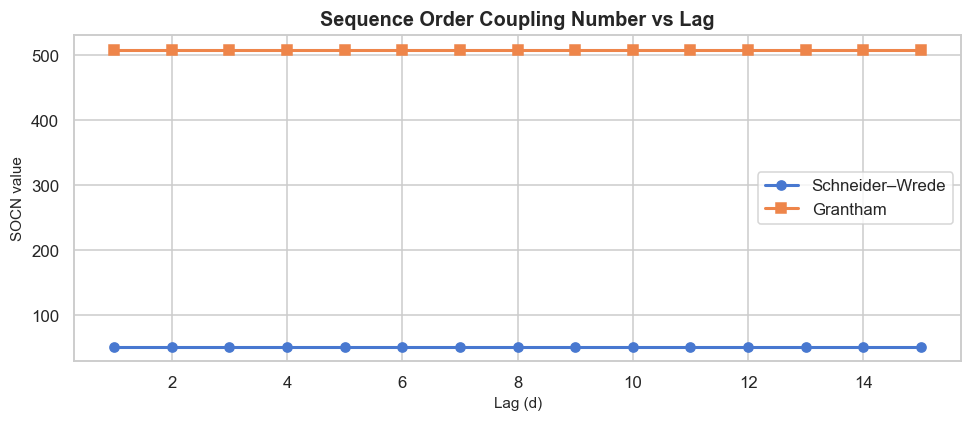

In [15]:
# ── Sequence Order Coupling Number across multiple lags ──────────────────────
max_lag = 15
socn_sw_vals, socn_gr_vals = [], []

for lag in range(1, max_lag + 1):
    sw = protpy.sequence_order_coupling_number(SEQ_SHORT, lag=lag, distance_matrix="schneider-wrede")
    gr = protpy.sequence_order_coupling_number(SEQ_SHORT, lag=lag, distance_matrix="grantham")
    socn_sw_vals.append(float(sw.values[0, 0]))
    socn_gr_vals.append(float(gr.values[0, 0]))

lags = list(range(1, max_lag + 1))
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(lags, socn_sw_vals, marker="o", label="Schneider–Wrede", linewidth=2)
ax.plot(lags, socn_gr_vals, marker="s", label="Grantham",        linewidth=2)
ax.set_title("Sequence Order Coupling Number vs Lag", fontsize=13, fontweight="bold")
ax.set_xlabel("Lag (d)")
ax.set_ylabel("SOCN value")
ax.legend()
plt.tight_layout()
plt.show()


QSO (Schneider-Wrede) shape : (1, 50)
QSO (Grantham) shape        : (1, 50)


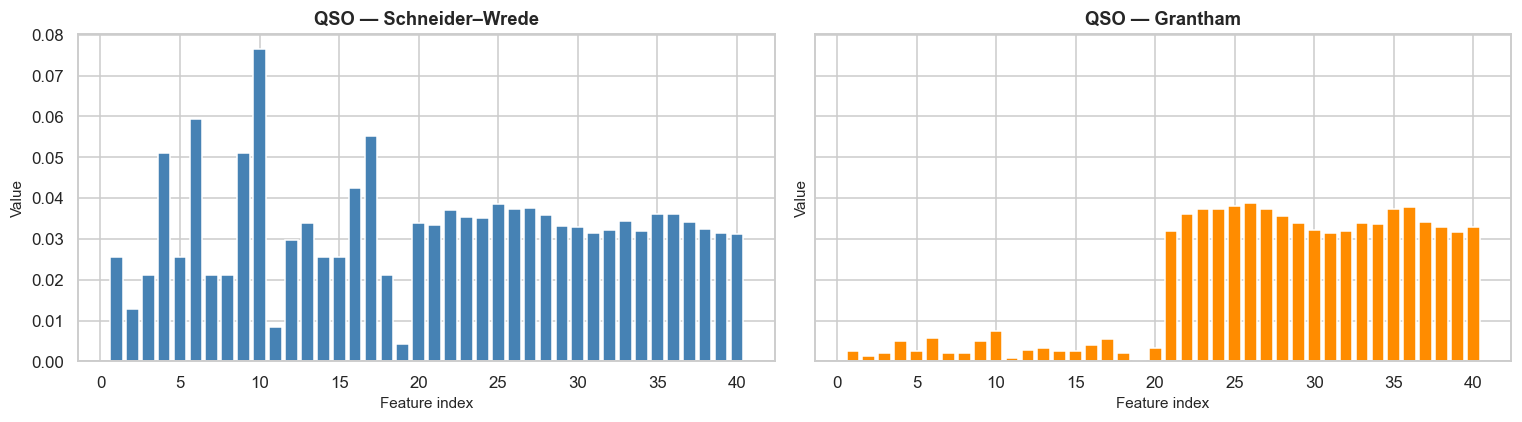

In [16]:
# ── Quasi Sequence Order ──────────────────────────────────────────────────────
qso_sw = protpy.quasi_sequence_order(SEQ_SHORT, distance_matrix="schneider-wrede")
qso_gr = protpy.quasi_sequence_order(SEQ_SHORT, distance_matrix="grantham")

print(f"QSO (Schneider-Wrede) shape : {qso_sw.shape}")
print(f"QSO (Grantham) shape        : {qso_gr.shape}")

# Side-by-side bar chart of first 40 features for each matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for ax, df, title, color in zip(
    axes,
    [qso_sw, qso_gr],
    ["QSO — Schneider–Wrede", "QSO — Grantham"],
    ["steelblue", "darkorange"],
):
    vals = df.values[0, :40]
    ax.bar(range(1, 41), vals, color=color, edgecolor="white")
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Feature index")
    ax.set_ylabel("Value")
plt.tight_layout()
plt.show()


## 11. Pseudo Amino Acid Composition (PseAAC)

PseAAC extends standard amino acid composition by incorporating sequence order information via correlation factors.  
**Standard PseAAC** uses physicochemical properties; **Amphiphilic PseAAC** further decomposes into hydrophobic and hydrophilic contributions.

In [17]:
# ── Standard PseAAC ───────────────────────────────────────────────────────────
pseaac = protpy.pseudo_amino_acid_composition(SEQ_SHORT)
print(f"PseAAC shape: {pseaac.shape}")

# ── Amphiphilic PseAAC ────────────────────────────────────────────────────────
apseaac = protpy.amphiphilic_pseudo_amino_acid_composition(SEQ_SHORT)
print(f"Amphiphilic PseAAC shape: {apseaac.shape}")


PseAAC shape: (1, 50)


Amphiphilic PseAAC shape: (1, 80)


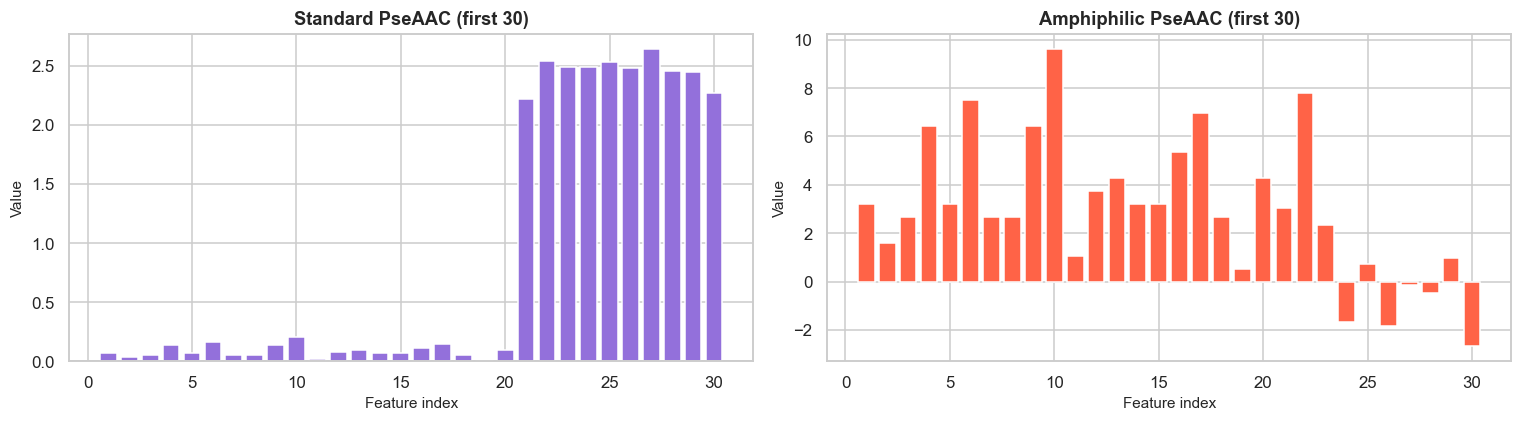

In [18]:
# ── Side-by-side comparison of first 30 components ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, df, title, color in zip(
    axes,
    [pseaac, apseaac],
    ["Standard PseAAC (first 30)", "Amphiphilic PseAAC (first 30)"],
    ["mediumpurple", "tomato"],
):
    vals = df.values[0, :30]
    ax.bar(range(1, len(vals) + 1), vals, color=color, edgecolor="white")
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Feature index")
    ax.set_ylabel("Value")

plt.tight_layout()
plt.show()


## 12. Performance Benchmarks

How long does each descriptor take to compute?  
We time a representative subset of descriptors on a single sequence and compare against the speed ratings stored in the `utils` registry.

In [19]:
import timeit

# ── Descriptors to benchmark (name -> callable) ───────────────────────────────
benchmarks = {
    "amino_acid_composition":               lambda: protpy.amino_acid_composition(SEQ_SHORT),
    "dipeptide_composition":                lambda: protpy.dipeptide_composition(SEQ_SHORT),
    "tripeptide_composition":               lambda: protpy.tripeptide_composition(SEQ_SHORT),
    "moreaubroto_autocorrelation":          lambda: protpy.moreaubroto_autocorrelation(SEQ_SHORT),
    "moran_autocorrelation":                lambda: protpy.moran_autocorrelation(SEQ_SHORT),
    "geary_autocorrelation":                lambda: protpy.geary_autocorrelation(SEQ_SHORT),
    "conjoint_triad":                       lambda: protpy.conjoint_triad(SEQ_SHORT),
    "ctd_composition":                      lambda: protpy.ctd_composition(SEQ_SHORT),
    "ctd_transition":                       lambda: protpy.ctd_transition(SEQ_SHORT),
    "ctd_distribution":                     lambda: protpy.ctd_distribution(SEQ_SHORT),
    "sequence_order_coupling_number":       lambda: protpy.sequence_order_coupling_number(SEQ_SHORT),
    "quasi_sequence_order":                 lambda: protpy.quasi_sequence_order(SEQ_SHORT),
    "pseudo_amino_acid_composition":        lambda: protpy.pseudo_amino_acid_composition(SEQ_SHORT),
    "amphiphilic_pseudo_amino_acid_composition": lambda: protpy.amphiphilic_pseudo_amino_acid_composition(SEQ_SHORT),
}

N_REPEAT = 3
results = {}
for name, fn in benchmarks.items():
    elapsed = timeit.timeit(fn, number=N_REPEAT) / N_REPEAT
    results[name] = elapsed
    print(f"  {name:<50} {elapsed*1000:7.2f} ms")


  amino_acid_composition                                0.42 ms
  dipeptide_composition                                 5.18 ms


  tripeptide_composition                              254.39 ms
  moreaubroto_autocorrelation                          10.81 ms
  moran_autocorrelation                                12.12 ms
  geary_autocorrelation                                14.45 ms
  conjoint_triad                                        3.86 ms
  ctd_composition                                       0.36 ms
  ctd_transition                                        0.35 ms
  ctd_distribution                                      0.49 ms
  sequence_order_coupling_number                        9.05 ms


  quasi_sequence_order                                 21.39 ms


  pseudo_amino_acid_composition                      2667.29 ms


  amphiphilic_pseudo_amino_acid_composition          1655.41 ms


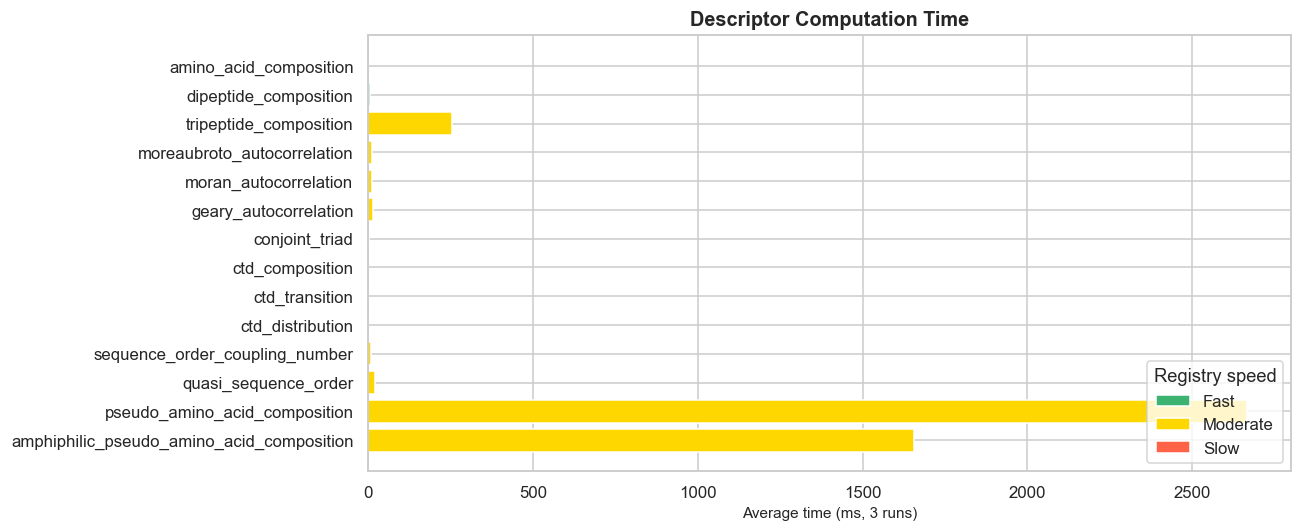

In [20]:
# ── Bar chart: measured time vs registry speed rating ────────────────────────
speed_colors = {"Fast": "mediumseagreen", "Moderate": "gold", "Slow": "tomato"}
bar_colors = [
    speed_colors.get(get_descriptor_info(n)["speed"], "steelblue")
    for n in results
]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(
    list(results.keys()),
    [v * 1000 for v in results.values()],
    color=bar_colors,
    edgecolor="white",
)
ax.set_xlabel("Average time (ms, 3 runs)")
ax.set_title("Descriptor Computation Time", fontsize=13, fontweight="bold")
ax.invert_yaxis()

# Legend for speed ratings
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=s) for s, c in speed_colors.items()]
ax.legend(handles=legend_elements, title="Registry speed", loc="lower right")

plt.tight_layout()
plt.show()


## 13. Visualization Dashboard

A combined overview figure showing: output dimensionality per descriptor, benchmark timings, and a feature-value heatmap across the three demo sequences.

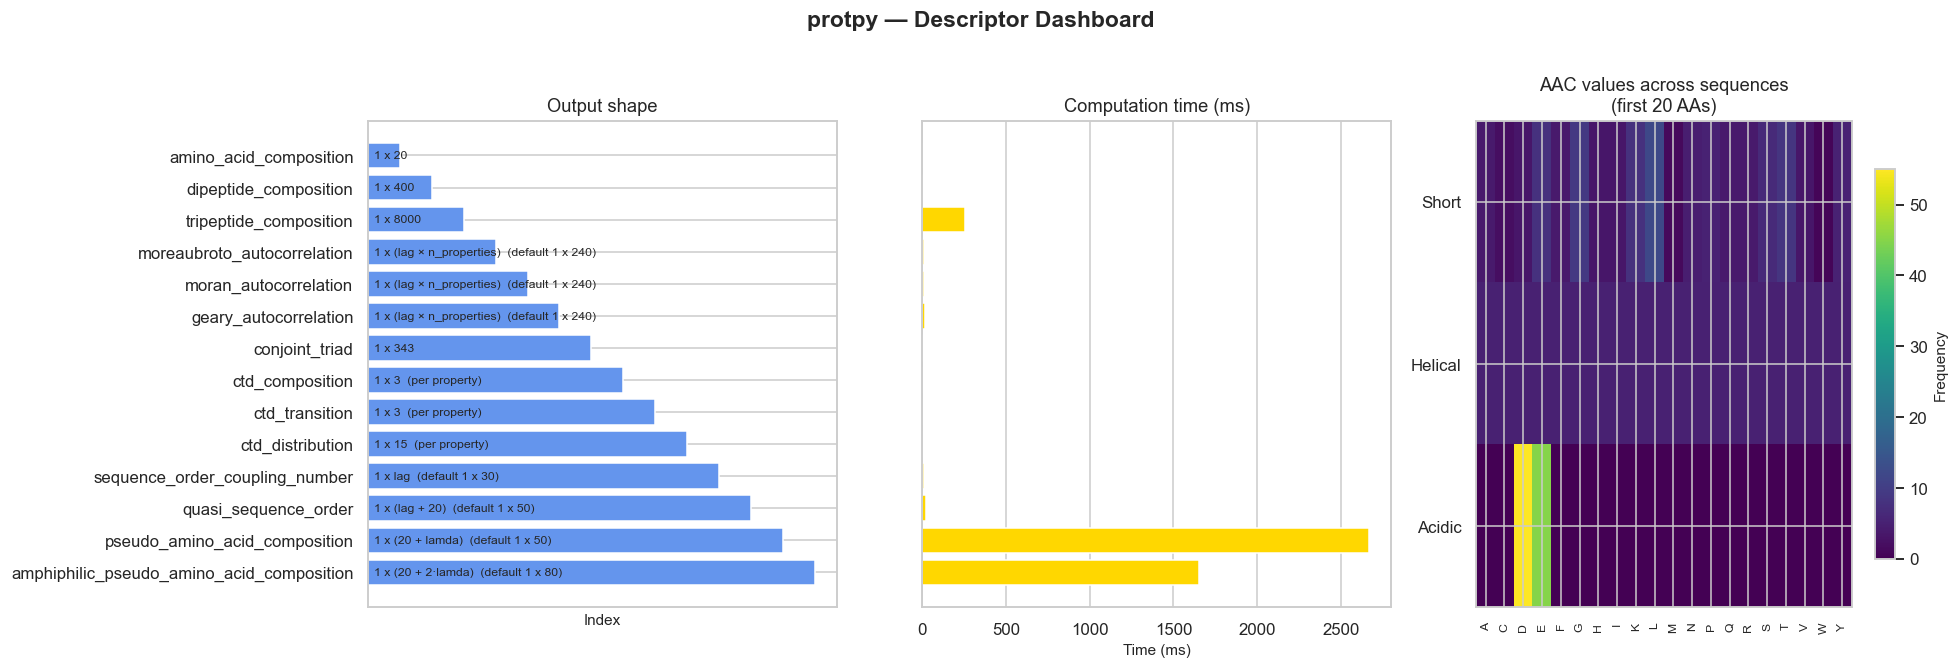

In [21]:
# ── Panel 1: output dimensionality per descriptor ────────────────────────────
# Only include the descriptors that were benchmarked (same order)
bench_names = list(results.keys())
output_dims = [get_descriptor_info(n)["output_shape"] for n in bench_names]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("protpy — Descriptor Dashboard", fontsize=15, fontweight="bold", y=1.01)

# ── Panel 1: output shape labels as text ─────────────────────────────────────
ax1 = axes[0]
ax1.barh(bench_names, range(1, len(bench_names) + 1), color="cornflowerblue", edgecolor="white")
for i, dim in enumerate(output_dims):
    ax1.text(0.2, i, dim, va="center", fontsize=8)
ax1.set_title("Output shape", fontsize=12)
ax1.set_xlabel("Index")
ax1.invert_yaxis()
ax1.set_xticks([])

# ── Panel 2: benchmark timing ─────────────────────────────────────────────────
ax2 = axes[1]
ax2.barh(
    bench_names,
    [results[n] * 1000 for n in bench_names],
    color=bar_colors,
    edgecolor="white",
)
ax2.set_title("Computation time (ms)", fontsize=12)
ax2.set_xlabel("Time (ms)")
ax2.invert_yaxis()
ax2.set_yticks([])   # labels already shown in panel 1

# ── Panel 3: feature heatmap across 3 demo sequences (first 20 features) ──────
ax3 = axes[2]

# Collect first 20 features of AAC for each sequence as a compact demo
heat_data = np.vstack([
    protpy.amino_acid_composition(s).values[0, :20] for s in SEQUENCES.values()
])
aa_cols = list(protpy.amino_acid_composition(SEQ_SHORT).columns[:20])
im = ax3.imshow(heat_data, aspect="auto", cmap="viridis")
ax3.set_xticks(range(20))
ax3.set_xticklabels(aa_cols, rotation=90, fontsize=8)
ax3.set_yticks(range(3))
ax3.set_yticklabels(list(SEQUENCES.keys()))
ax3.set_title("AAC values across sequences\n(first 20 AAs)", fontsize=12)
plt.colorbar(im, ax=ax3, shrink=0.8, label="Frequency")

plt.tight_layout()
plt.show()


---

## Summary

| Step | What we covered |
|------|----------------|
| 1 | Import protpy and define demo sequences |
| 2 | Enhanced type hints — subscripted generics in every module |
| 3 | F-string modernisation — replaced all `.format()` calls |
| 4 | `list_descriptors()` — discover all 36 descriptors by category |
| 5 | `get_descriptor_info()` — rich metadata for any descriptor |
| 6 | Amino Acid Composition (AAC) |
| 7 | Dipeptide & Tripeptide Composition |
| 8 | Autocorrelation descriptors (MoreauBroto / Moran / Geary) |
| 9 | CTD Composition, Transition and Distribution |
| 10 | Sequence Order Coupling Number & Quasi-Sequence Order |
| 11 | Pseudo Amino Acid Composition (standard & amphiphilic) |
| 12 | Performance benchmarks with registry speed cross-reference |
| 13 | Multi-panel visualization dashboard |

For the full API reference see the [protpy documentation](https://protpy.readthedocs.io).